C:\Users\He Entong\AppData\Local\Temp\ipykernel_44068\3442941838.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


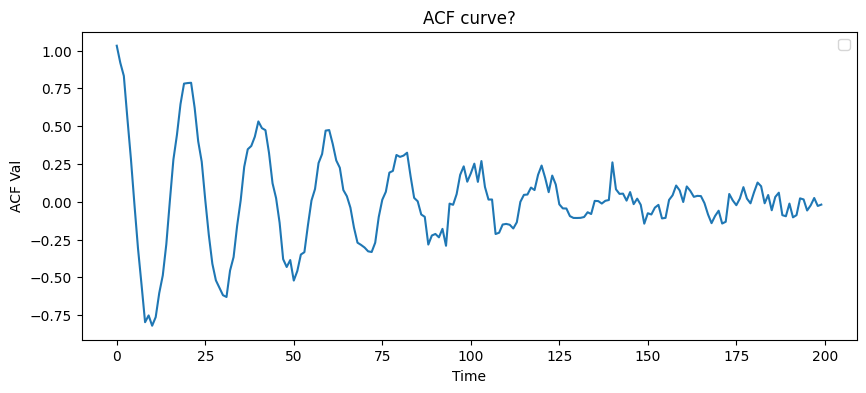

ACF data exported to acf_data.txt


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Parameters
T = 10.0      # Total time horizon
tau = 0.05    # Step size
decay = 0.3   # Exponential decay rate
freq = 1.0    # Oscillation frequency

# Time array
times = np.arange(0, int(T / tau))

# ACF-like curve: Exponential decay times a cosine (damped oscillation)
acf = np.exp(-decay * times * tau) * np.cos(2 * np.pi * freq * times * tau)

# Optional: Add some noise for realism
acf += 0.05 * np.random.randn(len(acf))

# Plot
plt.figure(figsize=(10,4))
plt.plot(times, acf)
plt.xlabel('Time')
plt.ylabel('ACF Val')
plt.title('ACF curve?')
plt.legend()
plt.show()


# export to a file to be read by C
path = 'acf_data.txt'
with open(path, 'w') as f:
    for t, a in zip(times, acf):
        f.write(f"{a}\n")
print(f"ACF data exported to {path}")

In [44]:
benchmark_path = './evaluation/CSI20250227_191018.csv'
csi_data = pd.read_csv(benchmark_path)
csi_data = csi_data['data'].apply(lambda x: eval(x)).to_numpy()
time_horizon = csi_data.shape[0]
num_subcarriers = len(csi_data[0]) // 2

In [67]:
csi_amp = np.zeros(time_horizon)
for i in range(time_horizon):
    for j in range(num_subcarriers):
        csi_amp_real = csi_data[i][2 * j]
        csi_amp_imag = csi_data[i][2 * j + 1]
        csi_amp[i] += (csi_amp_real ** 2 + csi_amp_imag ** 2) / 1e5



### Note ###
We use the autocorrelation function
$$
ACF_j = \frac{Cov(X_t, X_{t-j})}{Var(X_t)} = \frac{\sum_{t=j}^{n} (X_t - \bar{X})(X_{t-j} - \bar{X})}{\sum_{t=1}^{n} (X_t - \bar{X})^2}.
$$

In [78]:
def ACF(data):
    data_len = len(data)
    acf = np.zeros(data_len)
    data_mean = np.mean(data)
    data_shifted = data - data_mean
    for i in range(data_len):
        acf[i] = np.sum(data_shifted[:data_len - i] * data_shifted[i:])
    acf /= (np.var(data) * data_len)
    return acf

ACF data exported to acf_data.txt


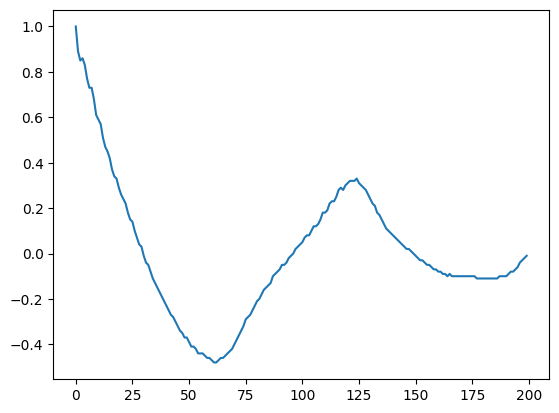

In [4]:
# window_size = 2000
# step_size = 50
# window_num = (time_horizon - window_size) // step_size + 1
# window_index = 30
# example_window = csi_amp[window_index * step_size: window_index * step_size + window_size]
# print(len(example_window))
# example_acf = ACF(example_window)
# print(len(example_acf))
# plt.figure(figsize=(50, 10))


example_acf = [1.00, 0.89, 0.85, 0.86, 0.83, 0.77, 0.73, 0.73, 0.68, 0.61, 0.59, 0.57, 0.51, 0.47, 0.45, 0.42, 0.37, 0.34, 0.33, 0.29, 0.26, 0.24, 0.22, 0.18, 0.15, 0.14, 0.10, 0.07, 0.04, 0.03, -0.01, -0.04, -0.05, -0.08, -0.11, -0.13, -0.15, -0.17, -0.19, -0.21, -0.23, -0.25, -0.27, -0.28, -0.30, -0.32, -0.34, -0.35, -0.37, -0.37, -0.39, -0.41, -0.41, -0.42, -0.44, -0.44, -0.44, -0.45, -0.46, -0.46, -0.47, -0.48, -0.48, -0.47, -0.46, -0.46, -0.45, -0.44, -0.43, -0.42, -0.40, -0.38, -0.36, -0.34, -0.32, -0.29, -0.28, -0.27, -0.25, -0.23, -0.21, -0.20, -0.18, -0.16, -0.15, -0.14, -0.13, -0.10, -0.09, -0.08, -0.07, -0.05, -0.05, -0.04, -0.02, -0.01, 0.00, 0.02,
            0.03, 0.04, 0.05, 0.07, 0.08, 0.08, 0.10, 0.12, 0.12, 0.13, 0.15, 0.18, 0.18, 0.19, 0.22, 0.23, 0.23, 0.25, 0.28, 0.29, 0.28, 0.30, 0.31, 0.32, 0.32, 0.32, 0.33, 0.31, 0.30, 0.29, 0.28, 0.26, 0.24, 0.22, 0.21, 0.18, 0.17, 0.15, 0.13, 0.11, 0.10, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02, 0.02, 0.01, -0.00, -0.01, -0.02, -0.03, -0.03, -0.04, -0.05, -0.05, -0.06, -0.07, -0.07, -0.08, -0.08, -0.09, -0.09, -0.10, -0.09, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.11, -0.10, -0.10, -0.10, -0.10, -0.09, -0.08, -0.08, -0.07, -0.06, -0.04, -0.03, -0.02, -0.01]
plt.plot(example_acf, label='ACF of example window')

# write the ACF to acf_data.txt
with open(path, 'w') as f:
    for a in example_acf:
        f.write(f"{a}\n")
print(f"ACF data exported to {path}")


In [ ]:
%%bash
gcc -w -o FFP find_first_peak.c
./FFP

Peak indices written to peak_indices.txt
Typical period min samples: 300, Typical period max samples: 600
First peak found at index: 406, data value: 0.025799
Estimated BPM: 14.778325


Peak indices read from peak_indices.txt: [124]
[0.913333, 0.9, 0.886, 0.84, 0.808, 0.784, 0.748, 0.704, 0.668, 0.636, 0.592, 0.55, 0.518, 0.484, 0.444, 0.41, 0.382, 0.35, 0.318, 0.292, 0.268, 0.238, 0.21, 0.186, 0.158, 0.128, 0.1, 0.076, 0.046, 0.018, -0.006, -0.03, -0.058, -0.082, -0.104, -0.128, -0.15, -0.17, -0.19, -0.21, -0.23, -0.248, -0.266, -0.284, -0.302, -0.318, -0.336, -0.35, -0.364, -0.378, -0.39, -0.4, -0.414, -0.424, -0.43, -0.438, -0.446, -0.45, -0.456, -0.464, -0.47, -0.472, -0.472, -0.47, -0.464, -0.456, -0.448, -0.44, -0.428, -0.414, -0.398, -0.38, -0.36, -0.338, -0.318, -0.3, -0.282, -0.264, -0.248, -0.232, -0.214, -0.196, -0.18, -0.166, -0.152, -0.136, -0.122, -0.108, -0.094, -0.078, -0.068, -0.058, -0.046, -0.034, -0.024, -0.01, 0.004, 0.016, 0.028, 0.042, 0.054, 0.064, 0.076, 0.09, 0.1, 0.11, 0.124, 0.14, 0.152, 0.166, 0.184, 0.2, 0.21, 0.224, 0.242, 0.256, 0.266, 0.28, 0.292, 0.3, 0.306, 0.314, 0.32, 0.32, 0.316, 0.31, 0.302, 0.288, 0.274, 0.258, 0.242, 0.222, 0.2

C:\Users\He Entong\AppData\Local\Temp\ipykernel_93792\3660541107.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


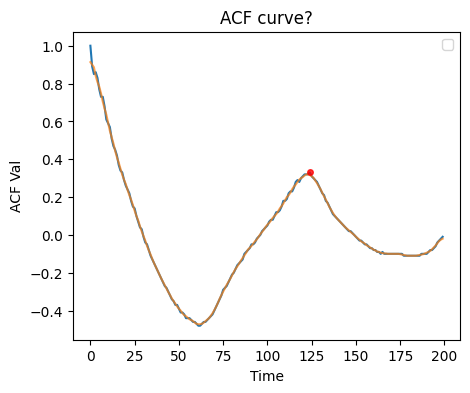

In [26]:
# write parsed peak indices from peak_indices.txt
peak_data_path = 'peak_indices.txt'
peak_indices = []
smoothed_data = []
with open(peak_data_path, 'r') as f:
    for line in f:
        peak_indices.append(int(line.strip()))
print(f"Peak indices read from {peak_data_path}: {peak_indices}")

with open("smoothed_data.txt", 'r') as f:
    for line in f:
        smoothed_data.append(eval(line.strip()))
print(smoothed_data)

peaks_val = [
    float(example_acf[i]) for i in peak_indices if i < len(example_acf)
]

print(f"Peak values: {peaks_val}")


plt.figure(figsize=(5,4))
horizon = [_ for _ in range(len(example_acf))]
plt.plot(horizon, example_acf, alpha=1.0)
plt.plot(horizon, smoothed_data, alpha=0.7)
plt.xlabel('Time')
plt.ylabel('ACF Val')
plt.title('ACF curve?')
plt.legend()
plt.plot(peak_indices, peaks_val, 'ro', label='Peaks', alpha=0.8, markersize=4)
first_peak = peak_indices[0]

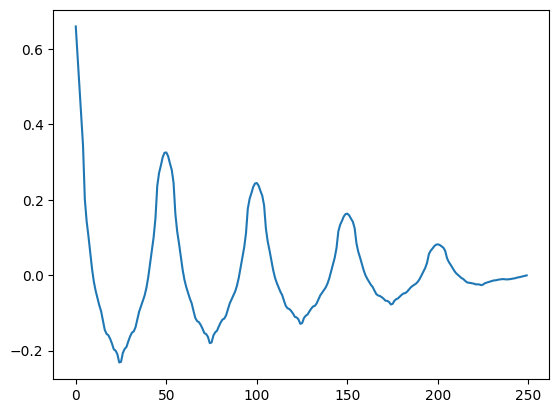

In [18]:
mrc_acf = []

with open("mrc_acf.txt", 'r') as file:
    for line in file:
        mrc_acf.append(float(line.strip()))

from scipy.signal import savgol_filter as sf 

mrc_acf = sf(mrc_acf, polyorder=1, window_length=10)

plt.plot(mrc_acf)

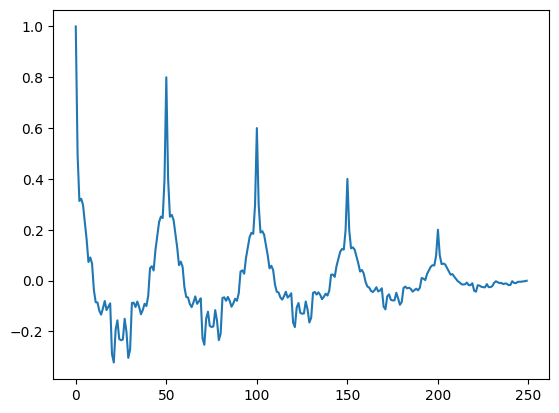

In [20]:
a  = [1.000000,0.497278,0.313328,0.322007,0.297755,0.229310,0.161790,0.073024,0.090810,0.066462,-0.037100,-0.085216,-0.086452,-0.118782,-0.134186,-0.109303,-0.080441,-0.116004,-0.102467,-0.089687,-0.289565,-0.322424,-0.194592,-0.156634,-0.229939,-0.234917,-0.232013,-0.150508,-0.202232,-0.304329,-0.271557,-0.088285,-0.087050,-0.104070,-0.082534,-0.103971,-0.132614,-0.115911,-0.091309,-0.100266,-0.061071,0.048586,0.056286,0.039544,0.120020,0.175031,0.229863,0.251760,0.245984,0.396588,0.800000,0.397959,0.251182,0.258255,0.239131,0.184383,0.130478,0.060516,0.074466,0.053679,-0.026192,-0.064607,-0.066701,-0.092705,-0.104542,-0.085606,-0.062332,-0.091552,-0.081410,-0.069912,-0.227218,-0.252785,-0.150500,-0.122507,-0.178611,-0.182713,-0.180685,-0.116381,-0.158141,-0.234690,-0.209210,-0.068510,-0.065993,-0.079617,-0.064425,-0.080274,-0.102969,-0.089834,-0.071558,-0.079657,-0.050163,0.035803,0.039942,0.027037,0.088708,0.130104,0.171239,0.188008,0.183838,0.297270,0.600000,0.298641,0.189037,0.194503,0.180507,0.139456,0.099166,0.048008,0.058122,0.040896,-0.015284,-0.043998,-0.046950,-0.066628,-0.074897,-0.061909,-0.044224,-0.067099,-0.060352,-0.050137,-0.164871,-0.183145,-0.106408,-0.088380,-0.127283,-0.130509,-0.129357,-0.082254,-0.114049,-0.165051,-0.146863,-0.048736,-0.044935,-0.055165,-0.046317,-0.056576,-0.073325,-0.063757,-0.051806,-0.059048,-0.039255,0.023020,0.023598,0.014529,0.057395,0.085178,0.112614,0.124256,0.121692,0.197951,0.400000,0.199322,0.126891,0.130751,0.121883,0.094530,0.067854,0.035501,0.041778,0.028113,-0.004377,-0.023389,-0.027199,-0.040551,-0.045253,-0.038212,-0.026116,-0.042646,-0.039295,-0.030363,-0.102524,-0.113506,-0.062317,-0.054253,-0.075955,-0.078306,-0.078029,-0.048127,-0.069958,-0.095412,-0.084516,-0.028961,-0.023878,-0.030712,-0.028209,-0.032879,-0.043680,-0.037680,-0.032055,-0.038439,-0.028347,0.010237,0.007254,0.002022,0.026083,0.040251,0.053990,0.060505,0.059546,0.098633,0.200000,0.100004,0.064745,0.066999,0.063258,0.049603,0.036541,0.022993,0.025434,0.015330,0.006531,-0.002780,-0.007447,-0.014474,-0.015608,-0.014515,-0.008008,-0.018194,-0.018237,-0.010588,-0.040178,-0.043867,-0.018225,-0.020126,-0.024627,-0.026102,-0.026701,-0.014000,-0.025866,-0.025772,-0.022169,-0.009186,-0.002820,-0.006259,-0.010101,-0.009182,-0.014036,-0.011603,-0.012304,-0.017830,-0.017439,-0.002547,-0.009090,-0.010486,-0.005229,-0.004676,-0.004634,-0.003247,-0.002599,-0.000686,]

plt.plot(a)